In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm, kstest, anderson
from sklearn.metrics import r2_score
import pandas as pd

In [2]:
# load data
radius_data = pd.read_csv('capsule_radius_all_medium.csv')


In [3]:
# remove lower 1% 
lower_bound = radius_data.capsule_radius.quantile(0.005)
radius_data = radius_data[radius_data.capsule_radius > lower_bound]


min: 3.96, max: 7.26


([<matplotlib.axis.XTick at 0x23054942ad0>,
 [Text(4, 0, '4'), Text(5, 0, '5'), Text(6, 0, '6'), Text(7, 0, '7')])

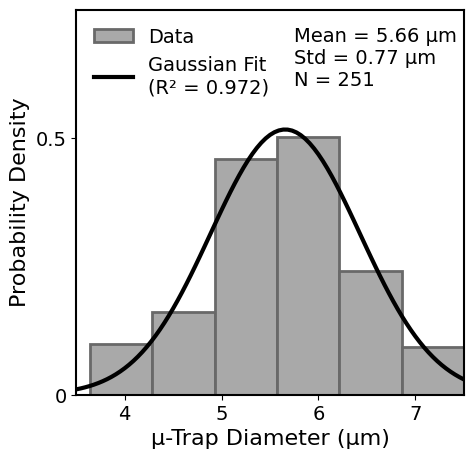

In [4]:
plt.figure(figsize=(5,5))

color = 'darkgray'
outline_color = 'dimgray'

# Histogram settings
bin_range = (3, 7.5)
# bin_range = (min(data_combined['major(um)'])-0.05, max(data_combined['major(um)']))
num_bins = 7
# Extract data
data = radius_data['capsule_radius']

# convert to um, and diameter
pixel_size = 110  # nm
data = data * pixel_size / 1000  # Convert to μm
data = data * 2  # Convert to diameter
print(f"min: {data.min()}, max: {data.max()}")
# remove outliers
# data = data[(data > 7) & (data < 12)]

# Fit a normal distribution to the data
mu, sigma = norm.fit(data)

# Generate x values for the fitted curve
x = np.linspace(bin_range[0], bin_range[1], 100)
pdf = norm.pdf(x, mu, sigma)  # Gaussian curve

# Compute R² (coefficient of determination)
hist_values, bin_edges = np.histogram(data, bins=num_bins, range=bin_range, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # Compute bin centers
expected_pdf = norm.pdf(bin_centers, mu, sigma)  # Expected Gaussian values at bin centers
r2 = r2_score(hist_values, expected_pdf)

# Perform Kolmogorov-Smirnov test
ks_stat, ks_pval = kstest(data, 'norm', args=(mu, sigma))

# Perform Anderson-Darling test
ad_result = anderson(data, dist='norm')

# Plot histogram
plt.hist(data, bins=num_bins, range=bin_range, edgecolor=outline_color, 
         color=color, alpha=1, density=True, linewidth=2, label="Data")

# Overlay Gaussian fit
plt.plot(x, pdf, 'k-', linewidth=3, label="Gaussian Fit\n(R² = {:.3f})".format(r2))

# Add text about mean, std, and goodness of fit
N = len(data)
text_str = (
    f"Mean = {mu:.2f} μm\n"
    f"Std = {sigma:.2f} μm\n"
    f"N = {N}\n"
)
plt.text(5.75, 0.56, text_str, fontsize=14)

# Axis labels
plt.xlabel('µ-Trap Diameter (μm)', fontsize=16)
plt.ylabel('Probability Density', fontsize=16)

# Adjust tick label size
ax = plt.gca()
ax.tick_params(axis='both', which='major', labelsize=12)

# Add legend
plt.legend(frameon=False, fontsize=14, loc='upper left')

# limits
plt.xlim(3.5, 7.5)
plt.ylim(0, 0.75)

# Font sizes
ax.tick_params(axis='both', which='major', labelsize=12)  # Tick label size

# Get the current content of the labels and title
xlabel = ax.get_xlabel()
ylabel = ax.get_ylabel()
title = ax.get_title()

# Set the font sizes without changing the content
ax.set_xlabel(xlabel, fontsize=16)  # X-axis label size
ax.set_ylabel(ylabel, fontsize=16)  # Y-axis label size
ax.set_title(title, fontsize=18)  # Title size

# Set legend size (if you have a legend)
legend = ax.get_legend()
if legend:
    for label in legend.get_texts():
        label.set_fontsize(14)

# Set text size for any additional annotations
for text in ax.texts:
    text.set_fontsize(14)

# Make axes thicker
for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_linewidth(1.5)

# Reduce num of ticks
# ax.locator_params(axis='y', nbins=2)
# ax.locator_params(axis='x', nbins=6)
# set y ticks
plt.yticks([0, 0.5], ['0', '0.5'], fontsize=14)# set x ticks
plt.xticks([4, 5, 6, 7], ['4', '5', '6', '7'], fontsize=14)

# Save figure as PNG (optional), transparent background, tight bounding box
# plt.savefig('Capsule_Diameter_Distribution_small.png', format='png', dpi=900, transparent=True, bbox_inches='tight')


# # Print goodness of fit statistics
# print("Gaussian Fit Parameters:")
# print(f"Mean (μ) = {mu:.3f}, Std (σ) = {sigma:.3f}")
# print(f"R² = {r2:.3f} (Goodness of Fit)")
